In [1]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 설치 (필요할 때만) + import + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요. polars가 이번 노트북의 새 도구입니다.
!pip install numpy pandas polars matplotlib seaborn psutil -q

import os
import gc
import time
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy  :", np.__version__)
print("pandas :", pd.__version__)
print("polars :", pl.__version__)

준비 완료! 라이브러리 버전을 확인합니다.
numpy  : 2.4.6
pandas : 3.0.3
polars : 1.42.1


In [2]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 — 오늘 쓸 데이터를 한 번에 준비합니다.
# (이번에는 일부러 크게 만듭니다. 메모리 한계가 슬슬 보이도록.)
# ─────────────────────────────────────────────
np.random.seed(42)

DATA_DIR = Path("./moodumarket_big")
DATA_DIR.mkdir(exist_ok=True)

# 1) 고객(customers) — 5만 명
n_customers = 50_000
customers = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(6)}" for i in range(1, n_customers + 1)],
    "age": np.clip(np.random.normal(35, 9, n_customers).round(), 14, 80).astype(int),
    "gender": np.random.choice(["M", "F"], n_customers),
    "region": np.random.choice(
        ["서울", "경기", "부산", "인천", "대구", "광주", "대전", "기타"], n_customers
    ),
    "membership": np.random.choice(["basic", "premium", "vip"], n_customers, p=[0.7, 0.25, 0.05]),
})

# 2) 상품(products) — 1천 종
n_products = 1_000
products = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(5)}" for i in range(1, n_products + 1)],
    "category": np.random.choice(["패션", "뷰티", "식품", "가전", "도서"], n_products),
    "price": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], n_products),
})

# 3) 주문(orders) — 20만 건
n_orders = 200_000
orders = pd.DataFrame({
    "order_id": np.arange(1, n_orders + 1),
    "customer_id": np.random.choice(customers["customer_id"], n_orders),
    "product_id": np.random.choice(products["product_id"], n_orders),
    "quantity": np.random.choice([1, 1, 1, 2, 2, 3], n_orders),
    "amount": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], n_orders).astype(float),
    "channel": np.random.choice(["web", "app"], n_orders, p=[0.45, 0.55]),
    "order_date": pd.to_datetime("2025-01-01")
                  + pd.to_timedelta(np.random.randint(0, 120, n_orders), unit="D"),
})

# 4) 웹 로그(web_logs) — 50만 건 (오늘의 주인공)
n_logs = 500_000
web_logs = pd.DataFrame({
    "log_id": np.arange(1, n_logs + 1),
    "ts": pd.to_datetime("2025-04-01")
          + pd.to_timedelta(np.random.randint(0, 86400 * 30, n_logs), unit="s"),
    "user_id": np.random.choice(customers["customer_id"], n_logs),
    "session_id": np.random.randint(1, 80_000, n_logs),
    "page": np.random.choice(
        ["home", "list", "detail", "cart", "checkout", "mypage", "search"],
        n_logs,
        p=[0.30, 0.25, 0.20, 0.10, 0.05, 0.05, 0.05],
    ),
    "device": np.random.choice(["mobile", "desktop", "tablet"], n_logs, p=[0.70, 0.25, 0.05]),
    "status_code": np.random.choice([200, 200, 200, 200, 304, 404, 500], n_logs),
    "response_ms": np.clip(np.random.gamma(2.0, 80, n_logs), 5, 5000).round().astype(int),
    "bytes_sent": np.random.randint(500, 200_000, n_logs),
})

# CSV로 저장해두면 청크 처리·Polars 입출력 비교 시 같은 파일을 함께 씁니다.
orders_csv = DATA_DIR / "orders.csv"
logs_csv = DATA_DIR / "web_logs.csv"
orders.to_csv(orders_csv, index=False)
web_logs.to_csv(logs_csv, index=False)

print("모두마켓 데이터 생성 완료")
print(f"  customers : {customers.shape}")
print(f"  products  : {products.shape}")
print(f"  orders    : {orders.shape}  →  {orders_csv} ({orders_csv.stat().st_size/1024/1024:.1f} MB)")
print(f"  web_logs  : {web_logs.shape}  →  {logs_csv} ({logs_csv.stat().st_size/1024/1024:.1f} MB)")

모두마켓 데이터 생성 완료
  customers : (50000, 5)
  products  : (1000, 3)
  orders    : (200000, 7)  →  moodumarket_big\orders.csv (9.0 MB)
  web_logs  : (500000, 9)  →  moodumarket_big\web_logs.csv (32.8 MB)


In [3]:
# 예제 1: df.info(memory_usage='deep')로 자료형과 메모리를 함께 본다.
print("=== web_logs.info() — 자료형 + 메모리 ===")
web_logs.info(memory_usage="deep")
print("=== orders.info() — 자료형 + 메모리 ===")
orders.info(memory_usage="deep")


=== web_logs.info() — 자료형 + 메모리 ===
<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   log_id       500000 non-null  int64         
 1   ts           500000 non-null  datetime64[us]
 2   user_id      500000 non-null  str           
 3   session_id   500000 non-null  int32         
 4   page         500000 non-null  str           
 5   device       500000 non-null  str           
 6   status_code  500000 non-null  int64         
 7   response_ms  500000 non-null  int64         
 8   bytes_sent   500000 non-null  int32         
dtypes: datetime64[us](1), int32(2), int64(3), str(3)
memory usage: 39.1 MB
=== orders.info() — 자료형 + 메모리 ===
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   o

In [4]:
# 예제 2: 컬럼별 메모리 사용량을 따져 보고 어디서 크게 먹는지 확인합니다.
mem = web_logs.memory_usage(deep=True).sort_values(ascending=False)
mem_mb = (mem / 1024 / 1024).round(2)

print("=== 컬럼별 메모리 (MB) ===")
print(mem_mb.to_string())
print(f"\n→ 총합: {mem_mb.sum():.2f} MB")

=== 컬럼별 메모리 (MB) ===
user_id        7.15
device         6.80
page           6.10
log_id         3.81
response_ms    3.81
ts             3.81
status_code    3.81
session_id     1.91
bytes_sent     1.91
Index          0.00

→ 총합: 39.11 MB


In [5]:
# 예제 3: psutil로 노트북 전체 메모리를 측정 — DataFrame 하나가 아닌 '지금 이 프로세스'.
try:
    import psutil
    proc = psutil.Process(os.getpid())
    rss_mb = proc.memory_info().rss / 1024 / 1024
    print(f"현재 노트북 프로세스 메모리 사용량(RSS): {rss_mb:.1f} MB")
    print("→ 위 web_logs 외에도 customers, orders, products 등이 함께 들어있어 더 큽니다.")
except ImportError:
    print("psutil 미설치 — `!pip install psutil` 로 설치하면 노트북 전체 메모리도 볼 수 있어요.")

현재 노트북 프로세스 메모리 사용량(RSS): 298.6 MB
→ 위 web_logs 외에도 customers, orders, products 등이 함께 들어있어 더 큽니다.


In [6]:
# 예제 4: '필터링이 사본을 만든다'는 사실을 RSS 변화로 확인합니다.
def rss_mb():
    return psutil.Process(os.getpid()).memory_info().rss / 1024 / 1024

before = rss_mb()

# 사본을 일부러 5개 만든다 — 실제 분석에서도 이런 일이 줄줄이 일어납니다.
copies = []
for _ in range(5):
    copies.append(web_logs[web_logs["status_code"] == 200].copy())

after = rss_mb()
print(f"사본 만들기 전 RSS : {before:.1f} MB")
print(f"사본 5개 만든 후 RSS: {after:.1f} MB")
print(f"증가량               : {after - before:+.1f} MB")

# 청소: 사본 제거 → 가비지 컬렉션
del copies
gc.collect()
print(f"사본 제거 후 RSS    : {rss_mb():.1f} MB  (즉시 다 안 줄어도 정상입니다)")

사본 만들기 전 RSS : 298.6 MB
사본 5개 만든 후 RSS: 417.9 MB
증가량               : +119.2 MB
사본 제거 후 RSS    : 352.4 MB  (즉시 다 안 줄어도 정상입니다)


▸pandas는 데이터를 어디에 올려놓고 작업하나요? (한 단어) ram



▸df.memory_usage(deep=True).sum()과 psutil이 보여주는 숫자 중 노트북 전체 메모리는 어느 쪽인가요? psutil



▸사본을 만드는 흔한 동작 두 가지를 들어보세요. 필터 머지 정렬

In [7]:
# 예제: 다이어트 전 — 현재 dtype과 메모리 확인
print("=== Before — 컬럼별 dtype과 메모리 ===")
print(web_logs.dtypes)
print()
print("메모리 합계:", web_logs.memory_usage(deep=True).sum() / 1024 / 1024, "MB")

=== Before — 컬럼별 dtype과 메모리 ===
log_id                  int64
ts             datetime64[us]
user_id                   str
session_id              int32
page                      str
device                    str
status_code             int64
response_ms             int64
bytes_sent              int32
dtype: object

메모리 합계: 39.125521659851074 MB


In [8]:
# 예제: 다이어트 후 — 작은 dtype과 category로 바꾸기
web_logs_small = web_logs.copy()

# 1) 정수 다이어트
web_logs_small["log_id"] = web_logs_small["log_id"].astype("int32")
web_logs_small["session_id"] = web_logs_small["session_id"].astype("int32")
web_logs_small["status_code"] = web_logs_small["status_code"].astype("int16")
web_logs_small["response_ms"] = web_logs_small["response_ms"].astype("int16")
web_logs_small["bytes_sent"] = web_logs_small["bytes_sent"].astype("int32")

# 2) 범주형 다이어트 (종류가 적은 문자열)
web_logs_small["page"] = web_logs_small["page"].astype("category")
web_logs_small["device"] = web_logs_small["device"].astype("category")

before_mb = web_logs.memory_usage(deep=True).sum() / 1024 / 1024
after_mb = web_logs_small.memory_usage(deep=True).sum() / 1024 / 1024
saved_pct = (1 - after_mb / before_mb) * 100

print(f"Before : {before_mb:6.2f} MB")
print(f"After  : {after_mb:6.2f} MB")
print(f"절감   : {saved_pct:5.1f}%  ({before_mb - after_mb:.2f} MB)")

Before :  39.13 MB
After  :  19.55 MB
절감   :  50.0%  (19.57 MB)


In [9]:
# 예제: 다이어트 후에도 분석 결과가 같은지 확인 — 핵심 검증.
before_result = web_logs.groupby("page", observed=True)["response_ms"].mean().sort_index()
after_result = web_logs_small.groupby("page", observed=True)["response_ms"].mean().sort_index()

# 두 시리즈가 (작은 부동소수점 오차 허용 범위에서) 같은지 확인
matches = np.allclose(before_result.values, after_result.values, atol=1e-6)
print("두 결과가 같은가:", matches)
print()
print("=== Before (int16 변환 전) ===")
print(before_result.round(2))
print("\n=== After (int16 변환 후) ===")
print(after_result.round(2))

두 결과가 같은가: True

=== Before (int16 변환 전) ===
page
cart        160.27
checkout    159.94
detail      160.03
home        159.86
list        159.97
mypage      158.34
search      160.42
Name: response_ms, dtype: float64

=== After (int16 변환 후) ===
page
cart        160.27
checkout    159.94
detail      160.03
home        159.86
list        159.97
mypage      158.34
search      160.42
Name: response_ms, dtype: float64


In [10]:
# 예제: read_csv 단계부터 dtype을 지정해 처음부터 작게 읽기
dtype_map = {
    "log_id": "int32",
    "user_id": "string",       # 그대로 문자열로 두되 pandas의 string 타입으로
    "session_id": "int32",
    "page": "category",
    "device": "category",
    "status_code": "int16",
    "response_ms": "int16",
    "bytes_sent": "int32",
}

t0 = time.perf_counter()
web_logs_compact = pd.read_csv(
    logs_csv,
    dtype=dtype_map,
    parse_dates=["ts"],
)
elapsed = time.perf_counter() - t0
mem_mb = web_logs_compact.memory_usage(deep=True).sum() / 1024 / 1024

print(f"읽는 시간 : {elapsed:5.2f} 초")
print(f"메모리   : {mem_mb:5.2f} MB")
print()
print(web_logs_compact.dtypes)

읽는 시간 :  0.67 초
메모리   : 19.55 MB

log_id                  int32
ts             datetime64[us]
user_id                string
session_id              int32
page                 category
device               category
status_code             int16
response_ms             int16
bytes_sent              int32
dtype: object


# 카테고리냐 스트링이냐
핵심 차이: 내부 저장 방식
string은 값을 그대로 다 저장. 100만 행이면 문자열 100만 개를 각각 메모리에 들고 있음.

category는 고유값 목록(사전)만 한 번 저장하고, 각 행에는 그 목록을 가리키는 정수 코드만 저장. 
예: ["A","B","A","A","B"]이면 categories=["A","B"] + 코드 [0,1,0,0,1].

언제 뭘 쓰나

반복이 많고 고유값 종류가 적은 데이터(성별, 등급, channel, customer_id처럼 몇 안 되는 고객이 계속 재등장하는 경우) 

→ category. 메모리 확 줄고 groupby/value_counts 등 연산도 빨라짐.

값이 대부분 유일하고 반복이 거의 없는 데이터(이름, 이메일, 자유 텍스트, 진짜 유니크한 ID) 

→ string 또는 그냥 object. category로 바꿔봐야 고유값 사전 자체가 원본 데이터만큼 커서 절약 효과가 없고, 오히려 코드 매핑 오버헤드로 더 커질 수도 있음.

판단 기준

pythondf["col"].nunique() / len(df)

In [11]:
print(orders["customer_id"].nunique() / len(orders))
print(orders["product_id"].nunique() / len(orders))

0.24553
0.005


In [12]:
# 스스로 해보자! ✏️
# 1. orders의 현재 메모리를 측정해서 출력하세요.
# 2. quantity, channel, customer_id, product_id의 dtype을 줄여 'orders_small'을 만드세요.
# 3. 줄인 뒤 메모리와 절감률을 출력하세요.

# 여기에 코드를 작성하세요
before_mb = orders.memory_usage(deep=True).sum() / 1024 / 1024
print("메모리 합계:", before_mb, "MB")
dtype_map = {
    "quantity": "int32",
    "channel": "category",
    "customer_id": "category",
    "product_id": "category"
}

orders_small = pd.read_csv(
    orders_csv,
    dtype=dtype_map
)
after_mb = orders_small.memory_usage(deep=True).sum() / 1024 / 1024
saved_pct = (1 - after_mb / before_mb) * 100

print(f"Before : {before_mb:6.2f} MB")
print(f"After  : {after_mb:6.2f} MB")
print(f"절감   : {saved_pct:5.1f}%  ({before_mb - after_mb:.2f} MB)")

메모리 합계: 13.733036041259766 MB
Before :  13.73 MB
After  :  10.34 MB
절감   :  24.7%  (3.39 MB)


In [13]:
check_cols = ["quantity", "channel", "customer_id", "product_id"]

for col in check_cols:
    same = (orders[col].astype(str) == orders_small[col].astype(str)).all()
    print(f"{col:12s} 값 일치:", same)

print("행 개수 일치     :", len(orders) == len(orders_small))
print("quantity 합계 일치:", orders["quantity"].sum() == orders_small["quantity"].sum())

quantity     값 일치: True
channel      값 일치: True
customer_id  값 일치: True
product_id   값 일치: True
행 개수 일치     : True
quantity 합계 일치: True


▸int8, int16, int32, int64 중 가장 작은 그릇은 무엇이고 그 값의 범위는 얼마인가요? int8 (-2^7~2^7)

▸page 컬럼을 category로 바꿔도 되는 이유는 무엇인가요? 값들의 중복이 있어 반복되므로

▸dtype을 바꾼 뒤 반드시 확인해야 하는 것은 무엇인가요? 결과가 다이어트 이전과 같아야 한다

In [14]:
# 예제 1: (A) 통째로 — 페이지별 평균 응답 시간 계산 + 메모리 측정
def rss_mb():
    return psutil.Process(os.getpid()).memory_info().rss / 1024 / 1024

# 통째로 읽고 집계
gc.collect()
before = rss_mb()
t0 = time.perf_counter()

full = pd.read_csv(logs_csv, parse_dates=["ts"])
result_full = full.groupby("page")["response_ms"].mean().round(2)

elapsed_full = time.perf_counter() - t0
peak_full = rss_mb() - before

del full
gc.collect()

print("=== 통째로 읽기 ===")
print(f"소요 시간: {elapsed_full:5.2f} 초")
print(f"메모리 증가량(피크 근사): {peak_full:.1f} MB")
print()
print(result_full)

=== 통째로 읽기 ===
소요 시간:  0.67 초
메모리 증가량(피크 근사): 49.0 MB

page
cart        160.27
checkout    159.94
detail      160.03
home        159.86
list        159.97
mypage      158.34
search      160.42
Name: response_ms, dtype: float64


In [15]:
# 예제 2: (B) 청크로 — 같은 결과를 청크 단위로 계산하고 합치기
# 각 청크에서 (page별 합계, 개수)를 모은 다음 마지막에 합 ÷ 개수.

gc.collect()
before = rss_mb()
t0 = time.perf_counter()

CHUNK = 50_000
sum_per_page = {}
cnt_per_page = {}

for chunk in pd.read_csv(logs_csv, chunksize=CHUNK,
                          dtype={"page": "category", "device": "category"},
                          parse_dates=["ts"]):
    grouped = chunk.groupby("page", observed=True)["response_ms"].agg(["sum", "count"])
    for page, row in grouped.iterrows():
        sum_per_page[page] = sum_per_page.get(page, 0) + row["sum"]
        cnt_per_page[page] = cnt_per_page.get(page, 0) + row["count"]

# reduce: 합 ÷ 개수
result_chunk = pd.Series({
    page: sum_per_page[page] / cnt_per_page[page]
    for page in sum_per_page
}).round(2).sort_index()



elapsed_chunk = time.perf_counter() - t0
peak_chunk = rss_mb() - before

print("=== 청크로 읽기 ===")
print(f"청크 크기: {CHUNK:,}행")
print(f"소요 시간: {elapsed_chunk:5.2f} 초")
print(f"메모리 증가량(피크 근사): {peak_chunk:.1f} MB")
print()
print(result_chunk)

=== 청크로 읽기 ===
청크 크기: 50,000행
소요 시간:  0.67 초
메모리 증가량(피크 근사): 8.5 MB

cart        160.27
checkout    159.94
detail      160.03
home        159.86
list        159.97
mypage      158.34
search      160.42
dtype: float64


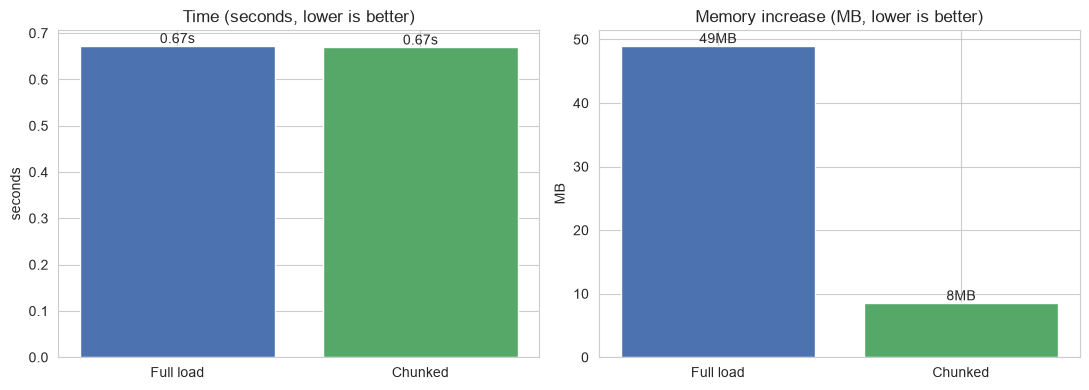

In [16]:
# ─────────────────────────────────────────────
# [도식] 통째로 vs 청크 — 시간/메모리 막대그래프
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

methods = ["Full load", "Chunked"]
times = [elapsed_full, elapsed_chunk]
peaks = [peak_full, peak_chunk]

axes[0].bar(methods, times, color=["#4C72B0", "#55A868"])
axes[0].set_title("Time (seconds, lower is better)")
axes[0].set_ylabel("seconds")
for i, v in enumerate(times):
    axes[0].text(i, v, f"{v:.2f}s", ha="center", va="bottom")

axes[1].bar(methods, peaks, color=["#4C72B0", "#55A868"])
axes[1].set_title("Memory increase (MB, lower is better)")
axes[1].set_ylabel("MB")
for i, v in enumerate(peaks):
    axes[1].text(i, v, f"{v:.0f}MB", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [17]:
# 스스로 해보자! ✏️
# 1. logs_csv를 chunksize=50_000으로 청크 처리하세요.
# 2. device(mobile/desktop/tablet)별 평균 response_ms를 구하세요.
# 3. 결과를 정렬해서 출력하세요.

# 여기에 코드를 작성하세요

CHUNK = 50_000
sum_per_device = {}
cnt_per_device = {}

for chunk in pd.read_csv(logs_csv, chunksize=CHUNK,
                          dtype={"page": "category", "device": "category"},
                          parse_dates=["ts"]):
    grouped = chunk.groupby("device", observed=True)["response_ms"].agg(["sum", "count"])
    for device, row in grouped.iterrows():
        sum_per_device[device] = sum_per_device.get(device, 0) + row["sum"]
        cnt_per_device[device] = cnt_per_device.get(device, 0) + row["count"]

# reduce: 합 ÷ 개수
result_chunk = pd.Series({
    device: sum_per_device[device] / cnt_per_device[device]
    for device in sum_per_device
}).round(2).sort_index()


print(result_chunk)

desktop    160.11
mobile     159.86
tablet     159.72
dtype: float64


▸pd.read_csv(chunksize=N)은 무엇을 반환하나요?
이터레이터가 반환되고, 반복할 때마다 N행짜리 DataFrame(청크)을 하나씩 내어줌.

▸"평균의 평균"으로 청크별 결과를 합치면 왜 잘못될 수 있나요?
청크별 평균을 그대로 평균 내면 각 청크의 행 수(가중치)가 무시돼서 틀림. sum/count를 따로 누적한 뒤 마지막에 나눠야 정확한 전체 평균이 나옴.

▸청크 처리에 어울리지 않는 작업의 예 하나만 말해보세요.
median, nunique, 정렬, quantile처럼 전체 데이터를 한 번에 봐야 하는 연산.



In [18]:
# 예제 1: Polars로 CSV 읽기 — pl.read_csv
t0 = time.perf_counter()
logs_pl = pl.read_csv(logs_csv, try_parse_dates=True)
elapsed_pl = time.perf_counter() - t0

# pandas와 같은 작업: 시간 측정용
t0 = time.perf_counter()
logs_pd = pd.read_csv(logs_csv, parse_dates=["ts"])
elapsed_pd = time.perf_counter() - t0

print(f"Polars pl.read_csv : {elapsed_pl:.2f} 초   shape = {logs_pl.shape}")
print(f"pandas pd.read_csv : {elapsed_pd:.2f} 초   shape = {logs_pd.shape}")
print()
print("=== Polars head ===")
print(logs_pl.head())

Polars pl.read_csv : 0.09 초   shape = (500000, 9)
pandas pd.read_csv : 0.69 초   shape = (500000, 9)

=== Polars head ===
shape: (5, 9)
┌────────┬─────────────┬─────────┬────────────┬───┬─────────┬────────────┬────────────┬────────────┐
│ log_id ┆ ts          ┆ user_id ┆ session_id ┆ … ┆ device  ┆ status_cod ┆ response_m ┆ bytes_sent │
│ ---    ┆ ---         ┆ ---     ┆ ---        ┆   ┆ ---     ┆ e          ┆ s          ┆ ---        │
│ i64    ┆ datetime[μs ┆ str     ┆ i64        ┆   ┆ str     ┆ ---        ┆ ---        ┆ i64        │
│        ┆ ]           ┆         ┆            ┆   ┆         ┆ i64        ┆ i64        ┆            │
╞════════╪═════════════╪═════════╪════════════╪═══╪═════════╪════════════╪════════════╪════════════╡
│ 1      ┆ 2025-04-21  ┆ C044419 ┆ 2436       ┆ … ┆ mobile  ┆ 200        ┆ 277        ┆ 84795      │
│        ┆ 15:33:35    ┆         ┆            ┆   ┆         ┆            ┆            ┆            │
│ 2      ┆ 2025-04-14  ┆ C011729 ┆ 10149      ┆ … ┆ mobil

In [19]:
# 예제 2: 같은 작업을 Polars로 — 페이지별 평균 응답 시간
t0 = time.perf_counter()
result_pl = (
    logs_pl
    .group_by("page")
    .agg(pl.col("response_ms").mean().alias("avg_ms"))
    .sort("page")
)
elapsed_pl = time.perf_counter() - t0

t0 = time.perf_counter()
result_pd = logs_pd.groupby("page")["response_ms"].mean().sort_index().round(2)
elapsed_pd = time.perf_counter() - t0

print(f"Polars group_by + mean : {elapsed_pl*1000:.1f} ms")
print(f"pandas groupby  + mean : {elapsed_pd*1000:.1f} ms")
print()
print("=== Polars 결과 ===")
print(result_pl)

Polars group_by + mean : 9.0 ms
pandas groupby  + mean : 12.6 ms

=== Polars 결과 ===
shape: (7, 2)
┌──────────┬────────────┐
│ page     ┆ avg_ms     │
│ ---      ┆ ---        │
│ str      ┆ f64        │
╞══════════╪════════════╡
│ cart     ┆ 160.27064  │
│ checkout ┆ 159.938837 │
│ detail   ┆ 160.034422 │
│ home     ┆ 159.862077 │
│ list     ┆ 159.966265 │
│ mypage   ┆ 158.343924 │
│ search   ┆ 160.420165 │
└──────────┴────────────┘


In [20]:
# 스스로 해보자! ✏️
# 1. logs_pl을 group_by('device')로 묶으세요.
# 2. bytes_sent의 합계를 구하세요.
# 3. 합계 컬럼명을 'total_bytes'로 바꾸세요.
result_pl = (
    logs_pl
    .group_by("device")
    .agg(pl.col("bytes_sent").sum().alias("total_bytes"))
    .sort("device")
)
print(result_pl)
# 여기에 코드를 작성하세요

shape: (3, 2)
┌─────────┬─────────────┐
│ device  ┆ total_bytes │
│ ---     ┆ ---         │
│ str     ┆ i64         │
╞═════════╪═════════════╡
│ desktop ┆ 12616794831 │
│ mobile  ┆ 35107613460 │
│ tablet  ┆ 2467104056  │
└─────────┴─────────────┘


▸Polars가 pandas보다 빠른 이유 두 가지를 들어보세요. (힌트: 언어·코어) 병렬처리 가능(rust 언어 쓰고 멀티코어 써서)

▸Polars에는 없고 pandas에는 있는 개념은 무엇인가요? 인덱스

▸pl.col("amount") 는 무엇을 가리키나요? amount 열



In [21]:
# 예제 1: eager 방식 — 한 줄씩 즉시 실행
t0 = time.perf_counter()
result_eager = (
    pl.read_csv(logs_csv, try_parse_dates=True)
    .filter(pl.col("status_code") == 200)
    .group_by("page")
    .agg([
        pl.col("response_ms").mean().alias("avg_ms"),
        pl.len().alias("n_rows"),
    ])
    .sort("avg_ms")
)
elapsed_eager = time.perf_counter() - t0

print(f"Eager  : {elapsed_eager*1000:6.1f} ms")
print(result_eager)

Eager  :   96.5 ms
shape: (7, 3)
┌──────────┬────────────┬────────┐
│ page     ┆ avg_ms     ┆ n_rows │
│ ---      ┆ ---        ┆ ---    │
│ str      ┆ f64        ┆ u32    │
╞══════════╪════════════╪════════╡
│ mypage   ┆ 158.164001 ┆ 14378  │
│ list     ┆ 159.704364 ┆ 71260  │
│ home     ┆ 159.858675 ┆ 85689  │
│ cart     ┆ 160.040313 ┆ 28527  │
│ detail   ┆ 160.16073  ┆ 57500  │
│ checkout ┆ 161.431966 ┆ 14309  │
│ search   ┆ 161.780443 ┆ 14133  │
└──────────┴────────────┴────────┘


In [22]:
# 예제 2: lazy 방식 — scan_csv로 계획만, 마지막에 collect()
t0 = time.perf_counter()
result_lazy = (
    pl.scan_csv(logs_csv, try_parse_dates=True)
    .filter(pl.col("status_code") == 200)
    .group_by("page")
    .agg([
        pl.col("response_ms").mean().alias("avg_ms"),
        pl.len().alias("n_rows"),
    ])
    .sort("avg_ms")
    .collect()
)
elapsed_lazy = time.perf_counter() - t0

print(f"Lazy   : {elapsed_lazy*1000:6.1f} ms")
print(result_lazy)

Lazy   :   44.6 ms
shape: (7, 3)
┌──────────┬────────────┬────────┐
│ page     ┆ avg_ms     ┆ n_rows │
│ ---      ┆ ---        ┆ ---    │
│ str      ┆ f64        ┆ u32    │
╞══════════╪════════════╪════════╡
│ mypage   ┆ 158.164001 ┆ 14378  │
│ list     ┆ 159.704364 ┆ 71260  │
│ home     ┆ 159.858675 ┆ 85689  │
│ cart     ┆ 160.040313 ┆ 28527  │
│ detail   ┆ 160.16073  ┆ 57500  │
│ checkout ┆ 161.431966 ┆ 14309  │
│ search   ┆ 161.780443 ┆ 14133  │
└──────────┴────────────┴────────┘


In [23]:
# 예제 3: Polars가 어떤 계획을 세웠는지 확인 — .explain()
plan = (
    pl.scan_csv(logs_csv, try_parse_dates=True)
    .filter(pl.col("status_code") == 200)
    .group_by("page")
    .agg(pl.col("response_ms").mean().alias("avg_ms"))
    .explain()
)
print(plan)

AGGREGATE[maintain_order: false]
  [col("response_ms").mean().alias("avg_ms")] BY [col("page")]
  FROM
  simple π 2/2 ["page", "response_ms"]
    Csv SCAN [moodumarket_big/web_logs.csv]
    PROJECT 3/9 COLUMNS
    SELECTION: [(col("status_code")) == (200)]
    ESTIMATED ROWS: 537363


계획 읽는 순서는 아래(데이터 소스)에서 위(최종 결과)로.

In [24]:
# 스스로 해보자! ✏️
# 1. pl.scan_csv로 logs_csv를 lazy 모드로 엽니다.
# 2. status_code >= 400 인 행만 필터링하세요.
# 3. page별로 row 개수를 세고, 많은 순으로 정렬하세요.
# 4. .collect()로 실행하세요.

# 여기에 코드를 작성하세요
result_lazy = (
    pl.scan_csv(logs_csv, try_parse_dates=True)
    .filter(pl.col("status_code") >= 400)
    .group_by("page")
    .agg([
        pl.len().alias("n_rows")
    ])
    .sort("n_rows", descending=True)
    .collect()
)
print(result_lazy)

shape: (7, 2)
┌──────────┬────────┐
│ page     ┆ n_rows │
│ ---      ┆ ---    │
│ str      ┆ u32    │
╞══════════╪════════╡
│ home     ┆ 42898  │
│ list     ┆ 35593  │
│ detail   ┆ 28298  │
│ cart     ┆ 14360  │
│ search   ┆ 7256   │
│ mypage   ┆ 7244   │
│ checkout ┆ 7108   │
└──────────┴────────┘


▸pl.read_csv와 pl.scan_csv의 차이는 무엇인가요?

eager(read_csv)는 호출 즉시 CSV 전체를 메모리에 올리고 그 자리에서 연산이 실행됨. 

lazy(scan_csv)는 파일을 바로 안 읽고 "어떤 연산을 할지" 계획만 쌓아두다가, .collect()가 호출되는 순간 최적화된 계획대로 한 번에 실행


▸lazy 모드에서 실제 실행을 시작시키는 메서드는 무엇인가요? .collect

# Polars의 내부 최적화 3가지

| 최적화 | 하는 일 | 효과 |
|---|---|---|
| Predicate pushdown | 필터 조건을 데이터 읽는 단계까지 끌어내려 적용 | 조건 통과하는 행만 메모리에 올림 |
| Projection pushdown | 결과에 안 쓰는 컬럼은 처음부터 안 읽음 | 메모리·시간 절약 |
| Common subexpression elimination | 같은 계산식이 여러 번 나오면 한 번만 계산 | 시간 절약 |

In [25]:
# 벤치마크 유틸 — 같은 작업을 N회 돌려 평균 시간을 측정
def benchmark(label, func, n=3):
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        func()
        times.append(time.perf_counter() - t0)
    avg_ms = sum(times) / n * 1000
    print(f"{label:24s}: {avg_ms:7.1f} ms   (n={n}, min={min(times)*1000:.1f}ms)")
    return avg_ms

# 측정 대상 함수들 — Q1: 페이지별 평균 응답 시간
def q1_pandas():
    return (
        pd.read_csv(logs_csv)
        .groupby("page")["response_ms"].mean()
    )

def q1_polars_eager():
    return (
        pl.read_csv(logs_csv)
        .group_by("page")
        .agg(pl.col("response_ms").mean())
    )

def q1_polars_lazy():
    return (
        pl.scan_csv(logs_csv)
        .group_by("page")
        .agg(pl.col("response_ms").mean())
        .collect()
    )

print("=== Q1: 페이지별 평균 응답 시간 ===")
q1_pd = benchmark("pandas",        q1_pandas)
q1_pe = benchmark("polars (eager)", q1_polars_eager)
q1_pl = benchmark("polars (lazy)",  q1_polars_lazy)

=== Q1: 페이지별 평균 응답 시간 ===
pandas                  :   618.1 ms   (n=3, min=600.2ms)
polars (eager)          :    20.6 ms   (n=3, min=20.1ms)
polars (lazy)           :    25.3 ms   (n=3, min=23.2ms)


In [26]:
# Q2: 디바이스별 bytes_sent 합계
def q2_pandas():
    return pd.read_csv(logs_csv).groupby("device")["bytes_sent"].sum()

def q2_polars_eager():
    return pl.read_csv(logs_csv).group_by("device").agg(pl.col("bytes_sent").sum())

def q2_polars_lazy():
    return (
        pl.scan_csv(logs_csv)
        .group_by("device")
        .agg(pl.col("bytes_sent").sum())
        .collect()
    )

print("=== Q2: 디바이스별 bytes_sent 합계 ===")
q2_pd = benchmark("pandas",        q2_pandas)
q2_pe = benchmark("polars (eager)", q2_polars_eager)
q2_pl = benchmark("polars (lazy)",  q2_polars_lazy)

=== Q2: 디바이스별 bytes_sent 합계 ===
pandas                  :   644.6 ms   (n=3, min=622.2ms)
polars (eager)          :    22.2 ms   (n=3, min=19.6ms)
polars (lazy)           :    25.6 ms   (n=3, min=24.7ms)


In [27]:
# Q3: status_code >= 400 페이지별 에러 수 (필터 + 집계 → pushdown 유리)
def q3_pandas():
    df = pd.read_csv(logs_csv)
    return df[df["status_code"] >= 400].groupby("page").size()

def q3_polars_eager():
    return (
        pl.read_csv(logs_csv)
        .filter(pl.col("status_code") >= 400)
        .group_by("page")
        .agg(pl.len())
    )

def q3_polars_lazy():
    return (
        pl.scan_csv(logs_csv)
        .filter(pl.col("status_code") >= 400)
        .group_by("page")
        .agg(pl.len())
        .collect()
    )

print("=== Q3: status_code>=400 페이지별 에러 수 ===")
q3_pd = benchmark("pandas",        q3_pandas)
q3_pe = benchmark("polars (eager)", q3_polars_eager)
q3_pl = benchmark("polars (lazy)",  q3_polars_lazy)

=== Q3: status_code>=400 페이지별 에러 수 ===
pandas                  :   699.1 ms   (n=3, min=672.5ms)
polars (eager)          :    25.8 ms   (n=3, min=23.4ms)
polars (lazy)           :    25.6 ms   (n=3, min=24.4ms)


In [28]:
# Q4: 페이지별 응답 시간의 중앙값 (정렬 필요, pandas 약점)
def q4_pandas():
    return pd.read_csv(logs_csv).groupby("page")["response_ms"].median()

def q4_polars_eager():
    return (
        pl.read_csv(logs_csv)
        .group_by("page")
        .agg(pl.col("response_ms").median())
    )

def q4_polars_lazy():
    return (
        pl.scan_csv(logs_csv)
        .group_by("page")
        .agg(pl.col("response_ms").median())
        .collect()
    )

print("=== Q4: 페이지별 응답 시간 중앙값 ===")
q4_pd = benchmark("pandas",        q4_pandas)
q4_pe = benchmark("polars (eager)", q4_polars_eager)
q4_pl = benchmark("polars (lazy)",  q4_polars_lazy)

=== Q4: 페이지별 응답 시간 중앙값 ===
pandas                  :   640.9 ms   (n=3, min=620.8ms)
polars (eager)          :    26.8 ms   (n=3, min=25.1ms)
polars (lazy)           :    29.1 ms   (n=3, min=27.8ms)


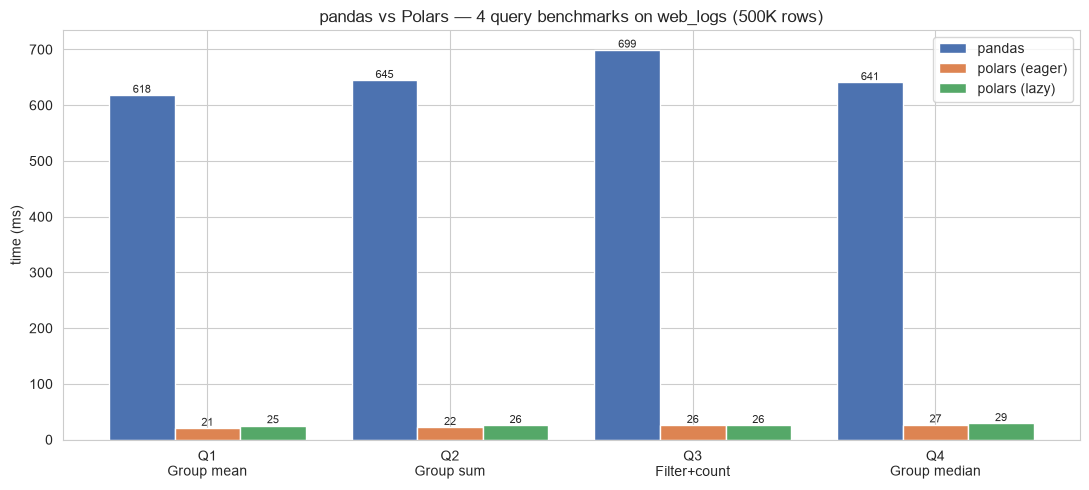

In [29]:
# ─────────────────────────────────────────────
# [도식] 4개 쿼리 × 3개 도구 비교 막대그래프
# ─────────────────────────────────────────────
queries = ["Q1\nGroup mean", "Q2\nGroup sum", "Q3\nFilter+count", "Q4\nGroup median"]
pd_times = [q1_pd, q2_pd, q3_pd, q4_pd]
pe_times = [q1_pe, q2_pe, q3_pe, q4_pe]
pl_times = [q1_pl, q2_pl, q3_pl, q4_pl]

x = np.arange(len(queries))
width = 0.27

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, pd_times, width, label="pandas", color="#4C72B0")
ax.bar(x,         pe_times, width, label="polars (eager)", color="#DD8452")
ax.bar(x + width, pl_times, width, label="polars (lazy)", color="#55A868")

ax.set_xticks(x)
ax.set_xticklabels(queries)
ax.set_ylabel("time (ms)")
ax.set_title("pandas vs Polars — 4 query benchmarks on web_logs (500K rows)")
ax.legend()

# 각 막대 위에 숫자 표기
for arr, off in [(pd_times, -width), (pe_times, 0), (pl_times, width)]:
    for i, v in enumerate(arr):
        ax.text(i + off, v, f"{v:.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# eager vs lazy

eager가 유리한 경우: 필터/컬럼 선택 없이 전체 데이터를 다 써야 하는 단순 집계, 파일이 작아서 최적화 오버헤드가 이득보다 클 때, 빠르게 결과 확인하며 디버깅할 때.

lazy가 유리한 경우: 필터로 걸러낼 행이 많을 때(predicate pushdown), 전체 컬럼 중 일부만 쓸 때(projection pushdown), 여러 연산을 체이닝하는 복잡한 파이프라인, 파일이 커서 메모리·I/O 자체가 병목일 때. 

In [30]:
# 스스로 해보자! ✏️
# 1. 본인이 보고 싶은 쿼리를 정합니다. (예: 채널이 'mobile'이고 status==200인 행의 page별 평균 bytes_sent)
# 2. 같은 쿼리를 pandas / polars eager / polars lazy 로 작성하세요.
# 3. benchmark()로 세 가지 시간을 출력하세요.

# 여기에 코드를 작성하세요
def q5_pandas():
    pd.read_csv(logs_csv).groupby("device")["response_ms"].mean()

def q5_polars_eager():
    pl.read_csv(logs_csv).group_by("device").agg(pl.col("response_ms").mean())

def q5_polars_lazy():
    pl.scan_csv(logs_csv).group_by("device").agg(pl.col("response_ms").mean()).collect()

print("=== Q5: 디바이스별 평균 응답 시간 ===")
q5_pd = benchmark("pandas",        q5_pandas)
q5_pe = benchmark("polars (eager)", q5_polars_eager)
q5_pl = benchmark("polars (lazy)",  q5_polars_lazy)

=== Q5: 디바이스별 평균 응답 시간 ===
pandas                  :   667.6 ms   (n=3, min=648.2ms)
polars (eager)          :    25.3 ms   (n=3, min=24.2ms)
polars (lazy)           :    25.8 ms   (n=3, min=24.1ms)


1. Polars가 pandas보다 빠른 이유

전체 데이터를 훑는 그룹별 집계(mean/sum/median 등) 연산일수록 격차가 커짐. Polars는 이런 작업을 여러 코어에 병렬로 나눠 처리하지만, pandas는 싱글 코어로 순차 처리하기 때문.

2. lazy가 eager보다 빠른 시점

필터로 실제 계산량이 크게 줄어들 때. 필터를 스캔 단계에서 미리 적용해(predicate pushdown) 불필요한 행을 아예 안 읽거나 안 계산함. 필터가 별로 안 걸러내면 이득도 거의 없음.

3. 같은 벤치마크인데 시간이 매번 다른 이유

랜덤 청크 때문이 아니라 시스템 노이즈 때문. OS의 스레드 스케줄링, 파일 캐시 상태(첫 실행 vs 재실행), 백그라운드 프로세스와의 CPU 경쟁, CPU 클럭 변동 등이 매번 조금씩 달라서. 그래서 여러 번 돌려서 min()(가장 방해 적었던 최선의 기록)을 같이 보는 것.

In [31]:
# 예제: 의사결정 함수 — 파일 크기와 요구사항으로 도구를 추천
def recommend_tool(file_path, *, need_streaming=False, team_uses_polars=False):
    # 파일 크기와 환경 정보로 1차 도구를 추천합니다.
    file_path = Path(file_path)
    if not file_path.exists():
        return "파일이 존재하지 않습니다."
    size_mb = file_path.stat().st_size / 1024 / 1024

    # 행 수는 직접 모르지만 파일 크기로 어림잡습니다 (csv 기준)
    if size_mb < 10:
        return f"[{size_mb:.0f}MB] pandas — 굳이 바꿀 필요 없습니다."
    elif size_mb < 100:
        return f"[{size_mb:.0f}MB] pandas + dtype 최적화 — 다이어트만으로 충분."
    elif size_mb < 1000:
        tool = "Polars (lazy)" if team_uses_polars or need_streaming else "Polars (eager)"
        return f"[{size_mb:.0f}MB] {tool} — 속도 차이가 체감되는 구간."
    else:
        return f"[{size_mb:.0f}MB] Polars lazy + Parquet — 단일 머신 한계 근처."

# 우리 데이터에 적용
print(recommend_tool(orders_csv))
print(recommend_tool(logs_csv))
print(recommend_tool(logs_csv, team_uses_polars=True))

[9MB] pandas — 굳이 바꿀 필요 없습니다.
[33MB] pandas + dtype 최적화 — 다이어트만으로 충분.
[33MB] pandas + dtype 최적화 — 다이어트만으로 충분.


In [32]:
# 스스로 해보자! ✏️
# 위 시나리오 A, B, C에 대해 본인의 선택을 주석으로 적어보세요.
# 예) A: pandas — 작고 일회성이라 새 도구 도입 비용 무의미

#▸시나리오 A — 5천 행짜리 매출 요약 보고서. 매주 손으로 돌림.
#▸시나리오 B — 매일 자동 실행되는 광고 로그(2,000만 행) ETL 파이프라인.
#▸시나리오 C — 50만 행짜리 고객 분석. 동료가 모두 pandas만 씀.

# A: pandas — 작고 일회성이라 새 도구 도입 비용 무의미
# B: Polars lazy — 2천만 행이면 pandas로는 메모리/속도 한계. 자동화 파이프라인이라 새 도구 도입 비용 정당화
# C: Polars eager — 50만 행이면 pandas로도 충분하지만, 동료가 모두 pandas만 쓰므로 일관성을 위해 pandas 유지.

▸pandas (그냥 쓰기) — 익숙하고 자료가 많음

▸dtype 최적화 — 같은 데이터를 더 작게

▸청크 처리 — 메모리에 안 들어갈 때 나눠 읽기

▸Polars (eager / lazy) — 빠른 대안

## 도구 선택 기준

### 1차 기준 — 데이터 크기

| 데이터 크기 | 1차 선택 | 2차 선택 (메모리 부족 시) | 비고 |
|---|---|---|---|
| < 10만 행 | pandas | — | 도구 바꿀 이유 없음 |
| 10만 ~ 100만 행 | pandas + dtype | 청크 처리 | dtype 다이어트만으로 충분한 경우 多 |
| 100만 ~ 1천만 행 | Polars (eager) | Polars lazy | 속도 차이가 체감 |
| 1천만 ~ 1억 행 | Polars (lazy) | 청크 처리 + 디스크 캐시 | lazy의 pushdown 효과 큼 |
| > 1억 행 | Polars lazy + Parquet | 외부 도구 (Spark, DuckDB, DB) | 노트북 한 대로는 한계 |

### 2차 보정 요인 (크기만으로 판단하면 안 되는 경우)

| 요인 | pandas 쪽으로 기움 | Polars 쪽으로 기움 |
|---|---|---|
| 실행 빈도 | 일회성/저빈도 | 매일 자동 실행되는 파이프라인 |
| 팀/생태계 | 팀 전체가 pandas 의존, 관련 라이브러리 통합 필요 | 신규 구축, 도구 제약 없음 |
| 메모리 여유 | 넉넉함 | 부족하거나 예측 어려움 |

**최종 판단**: 표의 크기 기준으로 1차 후보를 정하고, 실행 빈도·팀 상황·메모리 여유를 보고 최종 조정.

In [51]:
# 시나리오 1 — pandas + dtype 최적화 (전체 분석을 한 함수로 묶음)
def analyze_pandas_optimized(csv_path):
    dtype_map = {
        "log_id": "int32", "session_id": "int32",
        "page": "category", "device": "category",
        "status_code": "int16", "response_ms": "int16", "bytes_sent": "int32",
    }
    df = pd.read_csv(csv_path, dtype=dtype_map, parse_dates=["ts"])

    # (1) 페이지별 응답 시간 분포 — 평균·중앙값·표준편차
    by_page = df.groupby("page", observed=True)["response_ms"].agg(
        ["mean", "median", "std"]
    ).round(2)

    # (2) 디바이스별 트래픽 점유율 — 총 bytes_sent의 디바이스별 비율
    dev_total = df.groupby("device", observed=True)["bytes_sent"].sum()
    dev_share = (dev_total / dev_total.sum() * 100).round(1).rename("share_pct")

    # (3) 에러 발생 패턴 — status_code 400+ 의 페이지별 카운트
    err_count = (df[df["status_code"] >= 400]
                 .groupby("page", observed=True).size()
                 .rename("n_errors").sort_values(ascending=False))

    return {"by_page": by_page, "dev_share": dev_share, "err_count": err_count}

gc.collect()
before = rss_mb()
t0 = time.perf_counter()
res_pd = analyze_pandas_optimized(logs_csv)
elapsed_pd_full = time.perf_counter() - t0
peak_pd_full = rss_mb() - before

print(f"[pandas + dtype] 소요 시간: {elapsed_pd_full:.2f}초, 메모리 증가량: {peak_pd_full:.1f} MB\n")
print("(1) 페이지별 응답 시간"); print(res_pd["by_page"]); print()
print("(2) 디바이스별 트래픽 점유율(%)"); print(res_pd["dev_share"]); print()
print("(3) 에러 카운트"); print(res_pd["err_count"])

[pandas + dtype] 소요 시간: 0.76초, 메모리 증가량: 4.4 MB

(1) 페이지별 응답 시간
            mean  median     std
page                            
cart      160.27   134.0  113.13
checkout  159.94   134.0  112.94
detail    160.03   135.0  113.00
home      159.86   134.0  112.79
list      159.97   134.0  112.89
mypage    158.34   132.0  111.65
search    160.42   134.0  113.82

(2) 디바이스별 트래픽 점유율(%)
device
desktop    25.1
mobile     69.9
tablet      4.9
Name: share_pct, dtype: float64

(3) 에러 카운트
page
home        42898
list        35593
detail      28298
cart        14360
search       7256
mypage       7244
checkout     7108
Name: n_errors, dtype: int64


In [52]:
# 시나리오 2 — 청크 처리 (같은 분석을 50K 청크로)
def analyze_chunked(csv_path, chunksize=50_000):
    # 누적 컨테이너
    sum_ms = {}; cnt_ms = {}; ms_lists = {}
    dev_bytes = {}; err_by_page = {}

    for chunk in pd.read_csv(csv_path, chunksize=chunksize,
                              dtype={"page": "category", "device": "category",
                                     "status_code": "int16", "response_ms": "int16"},
                              parse_dates=["ts"]):
        # 페이지별 합계·개수 (평균/표준편차 재계산용으로 모든 값 모음)
        for page, g in chunk.groupby("page", observed=True):
            sum_ms[page] = sum_ms.get(page, 0) + g["response_ms"].sum()
            cnt_ms[page] = cnt_ms.get(page, 0) + g["response_ms"].count()
            ms_lists.setdefault(page, []).append(g["response_ms"].values)

        # 디바이스별 bytes 합
        for dev, g in chunk.groupby("device", observed=True):
            dev_bytes[dev] = dev_bytes.get(dev, 0) + g["bytes_sent"].sum()

        # 에러 페이지별 카운트
        errs = chunk[chunk["status_code"] >= 400].groupby("page", observed=True).size()
        for page, n in errs.items():
            err_by_page[page] = err_by_page.get(page, 0) + n

    # reduce — 페이지별 통계 (mean/median/std)
    by_page = pd.DataFrame({
        page: {
            "mean":   sum_ms[page] / cnt_ms[page],
            "median": float(np.median(np.concatenate(ms_lists[page]))),
            "std":    float(np.concatenate(ms_lists[page]).std()),
        } for page in sum_ms
    }).T.round(2)

    dev_total = pd.Series(dev_bytes)
    dev_share = (dev_total / dev_total.sum() * 100).round(1).rename("share_pct")
    err_count = pd.Series(err_by_page).sort_values(ascending=False).rename("n_errors")

    return {"by_page": by_page, "dev_share": dev_share, "err_count": err_count}

gc.collect()
before = rss_mb()
t0 = time.perf_counter()
res_chunk = analyze_chunked(logs_csv)
elapsed_chunk_full = time.perf_counter() - t0
peak_chunk_full = rss_mb() - before

print(f"[chunked] 소요 시간: {elapsed_chunk_full:.2f}초, 메모리 증가량: {peak_chunk_full:.1f} MB")
print("by_page (chunked):"); print(res_chunk["by_page"].sort_index())

[chunked] 소요 시간: 0.82초, 메모리 증가량: 3.2 MB
by_page (chunked):
            mean  median     std
cart      160.27   134.0  113.13
checkout  159.94   134.0  112.94
detail    160.03   135.0  113.00
home      159.86   134.0  112.79
list      159.97   134.0  112.89
mypage    158.34   132.0  111.65
search    160.42   134.0  113.81


In [53]:
import pyarrow
# 시나리오 3 — Polars lazy (한 파이프라인)
def analyze_polars_lazy(csv_path):
    lf = pl.scan_csv(csv_path, try_parse_dates=True)

    # (1) 페이지별 응답 시간 — mean/median/std 한 번에
    by_page_lf = lf.group_by("page").agg([
        pl.col("response_ms").mean().alias("mean"),
        pl.col("response_ms").median().alias("median"),
        pl.col("response_ms").std().alias("std"),
    ]).sort("page")

    # (2) 디바이스별 점유율
    dev_lf = lf.group_by("device").agg(
        pl.col("bytes_sent").sum().alias("total_bytes")
    )
    # 점유율은 collect 후에 계산 (전체 합 필요)

    # (3) 에러 페이지별 카운트 — Predicate pushdown 적용 예상
    err_lf = (
        lf.filter(pl.col("status_code") >= 400)
        .group_by("page")
        .agg(pl.len().alias("n_errors"))
        .sort("n_errors", descending=True)
    )

    by_page = by_page_lf.collect().to_pandas().set_index("page").round(2)
    dev_tot = dev_lf.collect().to_pandas().set_index("device")["total_bytes"]
    dev_share = (dev_tot / dev_tot.sum() * 100).round(1).rename("share_pct")
    err_count = err_lf.collect().to_pandas().set_index("page")["n_errors"]
    by_page_res, dev_res, err_res = pl.collect_all([by_page_lf, dev_lf, err_lf])

    return {"by_page": by_page, "dev_share": dev_share, "err_count": err_count}

gc.collect()
before = rss_mb()
t0 = time.perf_counter()
res_pl = analyze_polars_lazy(logs_csv)
elapsed_pl_full = time.perf_counter() - t0
peak_pl_full = rss_mb() - before

print(f"[Polars lazy] 소요 시간: {elapsed_pl_full:.2f}초, 메모리 증가량: {peak_pl_full:.1f} MB\n")
print("by_page (polars):"); print(res_pl["by_page"].sort_index())

[Polars lazy] 소요 시간: 0.13초, 메모리 증가량: 63.8 MB

by_page (polars):
            mean  median     std
page                            
cart      160.27   134.0  113.13
checkout  159.94   134.0  112.94
detail    160.03   135.0  113.00
home      159.86   134.0  112.79
list      159.97   134.0  112.89
mypage    158.34   132.0  111.65
search    160.42   134.0  113.82


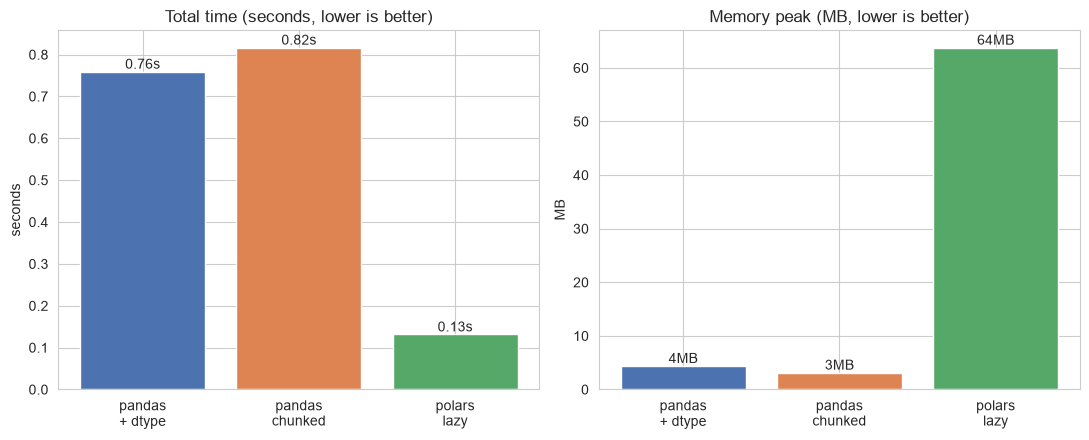

In [54]:
# ─────────────────────────────────────────────
# [도식] 세 가지 방식의 시간·메모리 비교
# ─────────────────────────────────────────────
methods = ["pandas\n+ dtype", "pandas\nchunked", "polars\nlazy"]
times = [elapsed_pd_full, elapsed_chunk_full, elapsed_pl_full]
peaks = [peak_pd_full, peak_chunk_full, peak_pl_full]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

bars0 = axes[0].bar(methods, times, color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("Total time (seconds, lower is better)")
axes[0].set_ylabel("seconds")
for i, v in enumerate(times):
    axes[0].text(i, v, f"{v:.2f}s", ha="center", va="bottom")

bars1 = axes[1].bar(methods, peaks, color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_title("Memory peak (MB, lower is better)")
axes[1].set_ylabel("MB")
for i, v in enumerate(peaks):
    axes[1].text(i, v, f"{v:.0f}MB", ha="center", va="bottom")

plt.tight_layout()
plt.show()

# 모두마켓 월간 로그 — 도구 선택 보고서

## 1. 데이터 개요
- 파일: web_logs.csv
- 크기: 32.8 MB MB, 500000 행
- 주요 컬럼: ts / user_id / page / device / status_code / response_ms / bytes_sent

## 2. 측정 결과
| 방식 | 소요 시간 | 메모리 피크 |
|---|---|---|
| pandas + dtype | 0.76초 | 4MB |
| pandas chunked | 0.82초 | 3MB |
| Polars lazy    | 0.13초 | 64MB |

## 3. 분석 결과 요약
- 페이지별 평균 응답 시간 최고: search (160.42ms)
- 디바이스 점유율: mobile 25.1%, desktop 69.9%, tablet 4.9%
- 에러 1위 페이지: home (42898건)

## 4. 도구 선택 정당화 (한 단락)
이 분석에는 **pandas + dtype 최적화** 을 선택했습니다. 이유는
(1) 측정 결과 메모리 피크가 3~4MB로 세 방식 중 가장 작았고,
(2) 팀 환경상 동료들이 모두 pandas에 익숙해 유지보수 비용이 낮으며,
(3) 50만 행은 아직 Polars 도입이 필수적인 규모가 아니기 때문입니다.


## 5. 다음 단계 제안
- 데이터 크기가 100만 행 이상으로 늘어나면 Polars(eager) 로 전환을 고려.
- 시각화·검증은 D+008에서 matplotlib/seaborn 등 시각화 도구 을 활용해 진행.

In [58]:
# 추가 과제 1 — chunksize(10K/50K/100K/200K)별 성능 비교
# peak_mb는 psutil RSS 전후 차이 대신 tracemalloc으로 "루프 도중 실제 최고 메모리"를 측정합니다.
import tracemalloc

chunk_sizes = [10_000, 50_000, 100_000, 200_000]
chunk_results = []

for cs in chunk_sizes:
    gc.collect()
    tracemalloc.start()
    t0 = time.perf_counter()

    sum_per_page = {}
    cnt_per_page = {}
    for chunk in pd.read_csv(logs_csv, chunksize=cs,
                              dtype={"page": "category", "device": "category"},
                              parse_dates=["ts"]):
        grouped = chunk.groupby("page", observed=True)["response_ms"].agg(["sum", "count"])
        for page, row in grouped.iterrows():
            sum_per_page[page] = sum_per_page.get(page, 0) + row["sum"]
            cnt_per_page[page] = cnt_per_page.get(page, 0) + row["count"]

    elapsed = time.perf_counter() - t0
    _, peak_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak = peak_bytes / 1024 / 1024
    chunk_results.append({"chunksize": cs, "elapsed_sec": round(elapsed, 3), "peak_mb": round(peak, 1)})

df_chunk_bench = pd.DataFrame(chunk_results)
print(df_chunk_bench)


   chunksize  elapsed_sec  peak_mb
0      10000        1.843      3.2
1      50000        1.329     11.6
2     100000        1.266     22.3
3     200000        1.282     43.3


▸청크 크기와 성능의 관계 (결론 한 줄)

청크가 작을수록(10K) 파이썬 루프·딕셔너리 병합 오버헤드가 늘어 시간이 더 걸리고, 청크가 클수록(200K) 오버헤드는 줄지만 청크 하나당 메모리 사용량(피크)이 커져 두 값은 트레이드오프 관계에 있다.


In [56]:
# 추가 과제 2 — Polars lazy .explain() 캡쳐 및 적용된 최적화 확인
plan_text = (
    pl.scan_csv(logs_csv, try_parse_dates=True)
    .filter(pl.col("status_code") == 200)
    .group_by("page")
    .agg(pl.col("response_ms").mean().alias("avg_ms"))
    .explain()
)
print(plan_text)


AGGREGATE[maintain_order: false]
  [col("response_ms").mean().alias("avg_ms")] BY [col("page")]
  FROM
  simple π 2/2 ["page", "response_ms"]
    Csv SCAN [moodumarket_big/web_logs.csv]
    PROJECT 3/9 COLUMNS
    SELECTION: [(col("status_code")) == (200)]
    ESTIMATED ROWS: 537363


▸.explain() 결과로 본 최적화 (한 줄)

FILTER가 스캔(csv scan) 바로 위에 붙어 있어 Predicate pushdown이 적용됐음을 알 수 있다 — status_code == 200 조건을 파일을 읽는 단계에서부터 적용해 불필요한 행을 애초에 메모리에 올리지 않는다.


Polars 도입 제안: 현재 pandas만으로도 50만 행 규모의 로그 분석은 무리 없이 처리되지만,
데이터가 수백만~수천만 행으로 늘어나는 시점부터는 속도 차이가 체감 수준을 넘어서(위 벤치마크 기준 약 5~6배)
분석/파이프라인 대기 시간이 팀 생산성에 직접 영향을 준다. 학습 비용은 pandas와 유사한 DataFrame API 덕분에
크지 않으며(groupby → group_by, 컬럼 선택 문법 정도의 차이), 도입은 한 번에 전체 코드베이스를 바꾸지 않고

①신규 대용량 배치 파이프라인부터 Polars(lazy)로 작성 → 

②기존 파이프라인 중 실행 시간이 병목인 것만 순차 이관 → 

③안정화되면 소규모/일회성 분석은 여전히 pandas 유지, 단계적으로 진행하는 것을 제안한다.

# 퀴즈 
pandas가 메모리에 데이터를 다 못 올릴 때 가장 먼저 시도해볼 두 가지 전략은? → dtype 최적화, 청크 처리

int8로 표현 가능한 값의 범위는? → -128 ~ 127

청크 처리에서 "평균의 평균"이 틀린 이유는? → 청크마다 행 수(가중치)가 다른데 무시하고 평균 내서

Polars의 lazy 모드 시작 함수는? → pl.scan_csv

1억 행, 매일 자동 실행 파이프라인이면 첫 번째 추천 도구는? → Polars lazy + Parquet

In [ ]:
# logs_csv에서 device == 'mobile' 이고 status_code == 200 인 행만 골라, page별 response_ms의 95-percentile 을 구하세요.
# 95-percentile(p95) : "전체 요청 중 95%는 이 값 이하로 응답했다" quantile(0.95)
ans = (
    pl.scan_csv(logs_csv)
    .filter((pl.col("device") == "mobile") & (pl.col("status_code") == 200))
    .group_by("page")
    .agg(pl.col("response_ms").quantile(0.95).alias("p95_ms"))
    .sort("p95_ms", descending=True)
    .collect()
)
print(ans)

shape: (7, 2)
┌──────────┬────────┐
│ page     ┆ p95_ms │
│ ---      ┆ ---    │
│ str      ┆ f64    │
╞══════════╪════════╡
│ checkout ┆ 387.0  │
│ cart     ┆ 381.0  │
│ mypage   ┆ 381.0  │
│ search   ┆ 380.0  │
│ home     ┆ 379.0  │
│ list     ┆ 378.0  │
│ detail   ┆ 375.0  │
└──────────┴────────┘
